# **ESERCIZIO 3.1**


**OBIETTIVI**

L'obiettivo di questa esercitazione è stimare il prezzo delle opzioni European Call e Put attraverso il metodo Monte Carlo:

- CALL OPTION: dà il diritto di acquistare un asset a un prezzo prefissato (lo strike price) al tempo di scadenza T
- PUT OPTION: dà il diritto di vendere l'asset al prezzo K al tempo T

In particoalre, il calcolo si fonda sulla teoria di Black-Scholes, che modella l'evoluzione temporale del prezzo di un asset come un moto browniano geometrico con tasso di interesse risk-free $r$ (che indica il rendimento di un investimento privo di rischio) e volatilità $\sigma$ (che indica l'intensità delle fluttuazioni del prezzo) costanti. Il moto Browniano geometrico è infatti adeguato per descrivere i prezzi degli asset, che sono sempre positivi.

Secondo questa teoria, per calcolare il prezzo dell'asset a un istante futuro si usa  la soluzione dell'equazione differenziale del Moto Browniano geometrico:

$$S(t) = S(0) \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right], \text{ con } W(t)\sim\mathcal{N}(0,t)$$

dove $W(t)$ indica il processo di Wiener, cioè un processo stocastico a incrementi indipendenti e distribuiti normalmente, con media nulla e varianza t, che descrive la parte aleatoria dell’evoluzione del prezzo.

Nello specifico, l'esercitazione chiede di determinare il prezzo delle opzioni al tempo iniziale $t=0$ per un asset caratterizzato dai parametri:
- Prezzo iniziale: $S(0) = 100$
- Scadenza: $T = 1$
- Strike price: $K = 100$
- Tasso di interesse risk-free: $r = 0.1$
- Volatilità: $\sigma = 0.25$

In particolare, l'esercizio chiede di implementare due diverse strategie per il campionamento:
1.  CAMPIONAMENTO DIRETTO: si stima il prezzo finale dell'asset $S(T)$
2.  CAMPIONAMENTO DISCRETIZZATO: si simula l'intero cammino del prezzo dell'asset suddividendo l'intervallo temporale $[0, T]$ in 100 sotto-intervalli ($S(0), S(t_1), ..., S(t_{100}=T)$)

Successivamente, bisogna analizzare la convergenza delle stime (utilizzando un numero totale di lanci $M \ge 10^4$) e calcolare le incertezze statistiche con il metodo del data blocking. Infine, bisogna confrontare graficamente i risultati numerici con la soluzione analitica.

**IMPLEMENTAZIONE**

Per prima cosa, definisco e implemento le funzioni Call e Put nel codice, prima del main:
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

In particolare, queste funzioni non mi servono direttamente nell'esercizio, ma le ho implementate per stampare i valori attesi per il confronto finale. Per implementare Call e Put ho quindi bisogno di implementare anche le funzioni:
- $ N(x) = \int_{-\infty}^{x} dz \, e^{-\frac{z^2}{2}} = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$, che indica la funzione cumulativa della gaussiana
-   $S(t) = S(0) \exp\left[ \left(r-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$ in cui $W(t)\sim\mathcal{N}(0,t)$

Per l'esercizio, le funzioni Call e Put si calcolano tramite il metodo Monte Carlo, come:

- $C=e^{-rT}\cdot \max[0,S_1-K], $ con $S_1=S(T)$ 
- $P=e^{-rT}\cdot \max[0,K-S_1], $ con $S_1=S(T)$ 

Infatti, il $\max[...]$ rappresenta il profitto lordo che si otterrebbe alla scadenza T: ad esempio per la Call, se il prezzo finale S è maggiore di K ho un guadagno, altrimenti l'opzione non ha valore in quanto $\max[0,S_1-K]=0$. L'esponenziale rappresenta il fattore di sconto, che quantifica la riduzione del valore di un pagamento futuro rispetto al suo equivalente attuale.

A questo punto procedo implementando il codice del main. Per entrambi i tipi di campionamento devo usare il metodo del data blocking, quindi in entrambi i casi devo eseguire un ciclo esterno sul numero di blocchi e un ciclo interno sui lanci per blocco.

1. CAMPIONAMENTO DIRETTO: per il campionamento diretto è sufficiente valutare la funzione $S(t)$ all'istante finale. Dunque, dopo aver generato $W = \sqrt{T}z\in\mathcal{N}[0,1]$, calcolo il valore di $S$ e implemento il metodo a blocchi
2. CAMPIONAMENTO DISCRETIZZATO: per il campionamento discretizzato devo invece simulare l'intero "percorso" del prezzo dell'asset e non solamente il suo valore finale. Per questo, aggiungo un ciclo for interno a quello dei lanci per blocco, in cui calcolo la funzione $S$ a ogni istante di tempo $t_i\in [0,T]$. In particolare, ho suddiviso l'intervallo $[0,T]$ in 100 $t_i$, ciascuno da $\frac{T}{100}=0.01$.

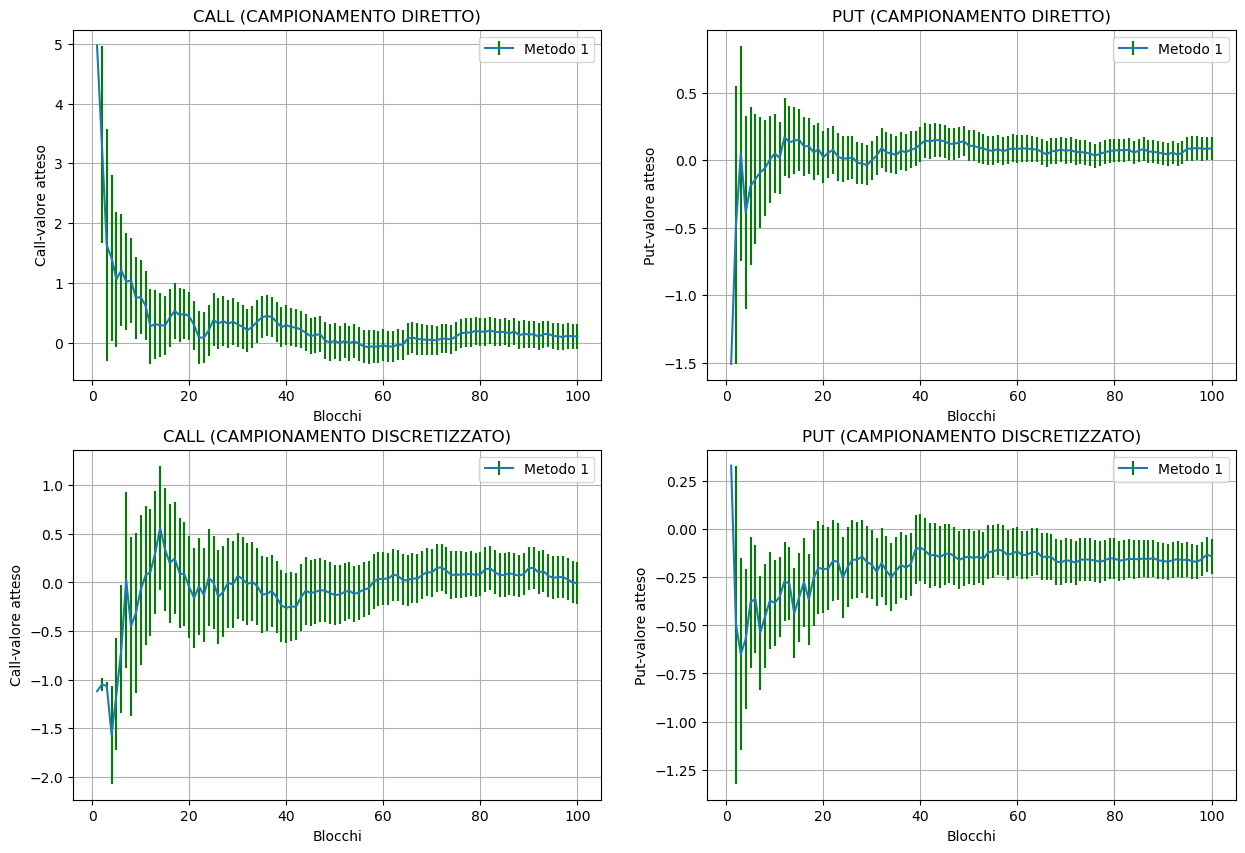

Errore blocco 100, Call, campionamento diretto:  0.213464
Errore blocco 100, Put, campionamento diretto:  0.0861599
Errore blocco 100, Call, campionamento discretizzato:  0.212919
Errore blocco 100, Put, campionamento discretizzato:  0.0913513


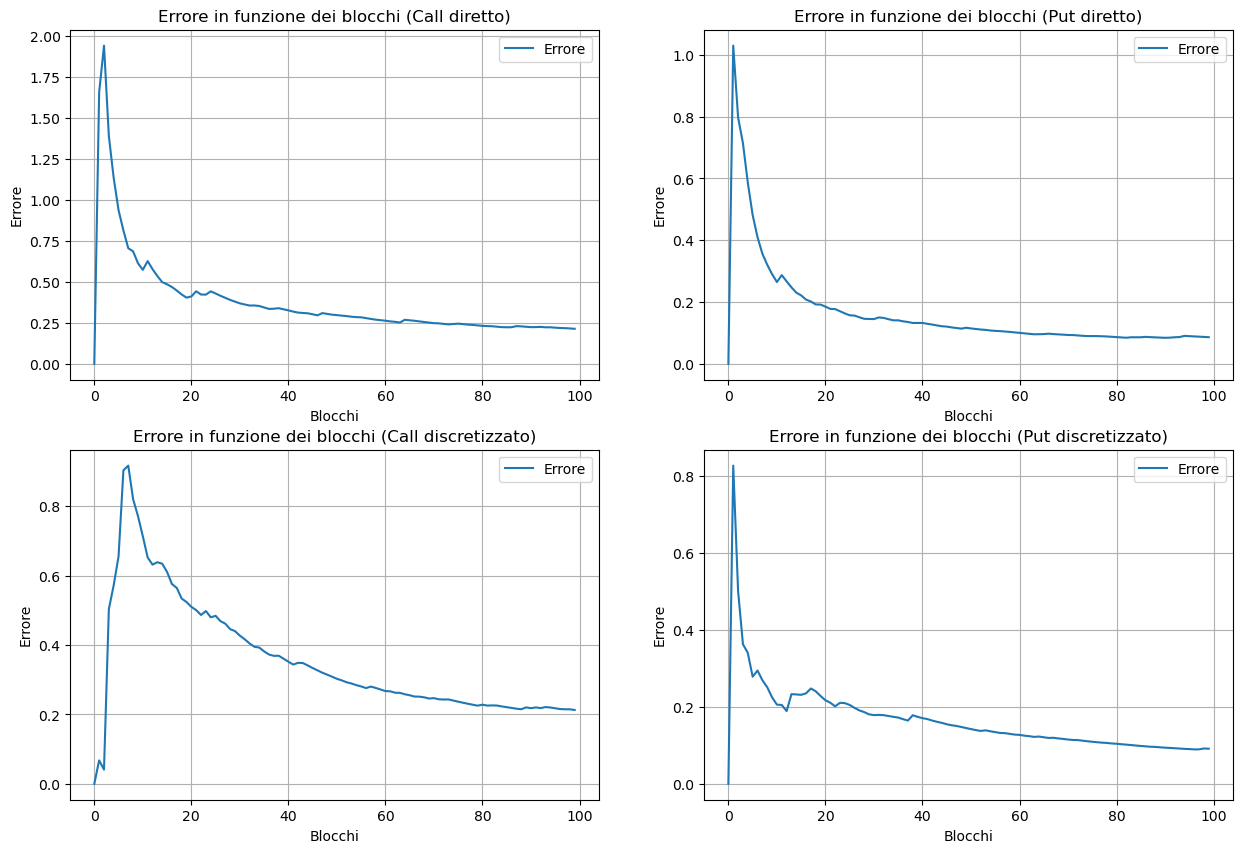

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#carico dati
call1=np.loadtxt("03.1/Call1.dat")
put1=np.loadtxt("03.1/Put1.dat")
dati=np.loadtxt("03.1/Attesi.dat")

x=call1[:,0] #numero blocco

y1=dati[0]
y2=dati[1]

call1_media=call1[:,1]
call1_errore=call1[:,2]

put1_media=put1[:,1]
put1_errore=put1[:,2]


plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.errorbar(x, call1_media-y1, yerr=call1_errore, ecolor='green', label="Metodo 1")
plt.xlabel('Blocchi')
plt.ylabel('Call-valore atteso')
plt.title("CALL (CAMPIONAMENTO DIRETTO)")
plt.grid(True)
plt.legend()


plt.subplot(2,2,2)
plt.errorbar(x, put1_media-y2, yerr=put1_errore, ecolor='green', label="Metodo 1")
plt.xlabel('Blocchi')
plt.ylabel('Put-valore atteso')
plt.title("PUT (CAMPIONAMENTO DIRETTO)")
plt.grid(True)
plt.legend()


call2=np.loadtxt("03.1/Call2.dat")
put2=np.loadtxt("03.1/Put2.dat")
dati=np.loadtxt("03.1/Attesi.dat")

x=call2[:,0]

y1=dati[0]
y2=dati[1]

call2_media=call2[:,1]
call2_errore=call2[:,2]

put2_media=put2[:,1]
put2_errore=put2[:,2]


plt.subplot(2,2,3)
plt.errorbar(x, call2_media-y1, yerr=call2_errore, ecolor='green', label="Metodo 1")
plt.xlabel('Blocchi')
plt.ylabel('Call-valore atteso')
plt.title("CALL (CAMPIONAMENTO DISCRETIZZATO)")
plt.grid(True)
plt.legend()


plt.subplot(2,2,4)
plt.errorbar(x, put2_media-y2, yerr=put2_errore, ecolor='green', label="Metodo 1")
plt.xlabel('Blocchi')
plt.ylabel('Put-valore atteso')
plt.title("PUT (CAMPIONAMENTO DISCRETIZZATO)")
plt.grid(True)
plt.legend()
plt.show()

#stampo errore dell'ultimo blocco
print("Errore blocco 100, Call, campionamento diretto: ", call1_errore[99])
print("Errore blocco 100, Put, campionamento diretto: ", put1_errore[99])
print("Errore blocco 100, Call, campionamento discretizzato: ",call2_errore[99])
print("Errore blocco 100, Put, campionamento discretizzato: ", put2_errore[99])

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(call1_errore,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Call diretto)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(put1_errore,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Put diretto)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(call2_errore,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Call discretizzato)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(put2_errore,label="Errore")
plt.xlabel('Blocchi')
plt.ylabel('Errore')
plt.title("Errore in funzione dei blocchi (Put discretizzato)")
plt.legend()
plt.grid(True)
plt.show()


**COMMENTO AI RISULTATI**

In tutti e quattro i grafici, che mostrano l'andamento rispettivamente di $C-C_\text{atteso}$ e di $P-P_\text{atteso}$ la curva tende a stabilizzarsi intorno allo zero all'aumentare del numero di blocchi. Questo indica che le stime fatte con il metodo Monte Carlo stanno convergendo ai valori analitici attesi per la Call per la Put, per entrambi i metodi. Questo avviene perchè entrambi descrivono lo stesso processo stocastico sottostante, anche se in due modi diversi: il metodo diretto genera direttamente il valore finale S(T), mentre quello discretizzato ne ricostruisce il cammino tramite incrementi gaussiani del processo di Wiener. Di conseguenza, entrambi campionano la stessa distribuzione finale e convergono pertanto agli stessi valori attesi.

Per quanto riguarda l'errore, in tutti i grafici l'altezza delle barre d'errore diminuisce progressivamente all'aumentare dei blocchi: questo è coerente con il Teorema del Limite Centrale. Inoltre, sempre per quanto riguarda l'errore, stampando quello associato all'ultimo blocco noto che errore calcolato col metodo discretizzato e quello ottenuto col metodo diretto sono confrontabili; al contrario, l'errore della Put è $\sim 2.3$ volte più piccolo di quello della Call. La risposta a questo andamento potrebbe trovarsi nel modo in cui Call e Put vengono stimate: infatti la Call ha come fattore moltiplicativo $\max (0, S_1-K)$, mentre la Put $\max (0, K-S_1)$. $K$ è lo strike price ed è fissato a 100, quindi $K-S_1$ è limitato superiormente e per questo motivo il valore calcolato per la Put risulta essere meno disperso e di conseguenza l'errore è minore. Al contrario, il fattore $S_1-K$ della Call non è limitato superiormente ed è quindi interessato da fluttuazioni più ampie.